# Stage 7 Homework — Outliers + Risk Assumptions
In this assignment you will implement outlier detection/handling and run a simple sensitivity analysis.

**Chain:** In the lecture, we learned detection (IQR, Z-score), options for handling (remove/winsorize), and sensitivity testing. Now, you will adapt those methods to a provided dataset and document the risks and assumptions behind your choices.

## Setup - Generate the Dataset

This cell creates the required folder structure (`data/raw/` and `data/processed/`) relative to the notebook, and generates the sample CSV dataset: business-day dates from 2022-01-03 to 2022-06-10, a `daily_return` column that sits slightly lower before May, five large shock values injected in May, and a second column `daily_return_2` correlated with the first. The dataset has NO missing values - filling those in was stage 06; this stage is about outliers. 
It saves the file under `data/raw/`; the load cell below reads back that same path from the `csv_path` variable, so the filename is written in exactly one place.

In [48]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn

In [49]:
import os
import numpy as np
import pandas as pd

# Define folder paths relative to this notebook
raw_dir = 'data/raw'
processed_dir = 'data/processed'

# Create folders if they don't exist
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

# Generate business day dates
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")

# Fixed random seed for reproducibility
np.random.seed(17)

# Column 1: daily_return ~ N(0, 0.01)
returns = np.random.normal(0, 0.01, size=len(dates))
mask_pre_may = dates < "2022-05-01"
returns[mask_pre_may] -= 0.0015  

# Inject "shock" values
shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294
}
for d, v in shock_values.items():
    idx = np.where(dates == pd.to_datetime(d))[0][0]
    returns[idx] = v

# Column 2: daily_return_2, correlated with daily_return + small noise
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

# Create DataFrame with two numeric columns
df = pd.DataFrame({
    "date": dates,
    "daily_return": returns,
    "daily_return_2": daily_return_2
})

# Save to CSV in raw data folder
csv_path = os.path.join(raw_dir, 'outliers_homework.csv')
if not os.path.exists(csv_path):
    df.to_csv(csv_path, index=False)
    print(f'Synthetic dataset with two columns created and saved to {csv_path}')
else:
    print(f'File already exists at {csv_path}. Skipping CSV creation to avoid overwrite.')

File already exists at data/raw/outliers_homework.csv. Skipping CSV creation to avoid overwrite.


In [50]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
np.random.seed(17)

## Load Data (provided or synthetic fallback)

In [51]:
data_path = Path(csv_path)   # the SAME variable the Setup cell saved to, so the filename is
                             # defined once, up there - renaming it there is enough
if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback: linear trend with noise and a few extremes
    x = np.linspace(0, 10, 200)
    y = 2.2 * x + 1 + np.random.normal(0, 1.2, size=x.size)
    y[10] += 15; y[120] -= 13; y[160] += 18
    df = pd.DataFrame({'x': x, 'y': y})
df.head()

,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


## Outlier Functions - Sample Implementations (required)

Both functions below already work. Your job is to **read them, improve them, and then use them** - not to retype them. Worth improving: they silently accept an empty series; they do not state what happens to `NaN`; `detect_outliers_zscore` uses the population standard deviation (`ddof=0`) without saying why; and neither checks that `k` or `threshold` is positive. Document whatever you change, and say in your reflection why it mattered.

In [52]:
def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Return a boolean mask for IQR-based outliers.

    NaN values are ignored and returned as False.
    k must be positive.
    """
    if series.empty:
        raise ValueError("Series cannot be empty.")

    if k <= 0:
        raise ValueError("k must be positive.")

    clean_series = series.dropna()

    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    return ((series < lower) | (series > upper)).fillna(False)

def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Return a boolean mask for Z-score outliers.

    NaN values are ignored and returned as False.
    Uses population standard deviation (ddof=0).
    threshold must be positive.
    """
    if series.empty:
        raise ValueError("Series cannot be empty.")

    if threshold <= 0:
        raise ValueError("threshold must be positive.")

    clean_series = series.dropna()

    mu = clean_series.mean()
    sigma = clean_series.std(ddof=0)

    if sigma == 0:
        return pd.Series(False, index=series.index)

    z = (series - mu) / sigma

    return (z.abs() > threshold).fillna(False)

*(Stretch)* A working `winsorize_series` is provided below. Improve it if you can - it does not check that `lower` is below `upper` - then use it in the comparison further down.

In [53]:
def winsorize_series(series: pd.Series, lower: float = 0.05, upper: float = 0.95) -> pd.Series:
    """Winsorize a series by clipping values to lower and upper quantiles"""

    if not 0 <= lower < upper <= 1:
        raise ValueError("lower and upper must satisfy 0 <= lower < upper <= 1.")

    lo = series.quantile(lower)
    hi = series.quantile(upper)

    return series.clip(lower=lo, upper=hi)

## Apply Detection and Create Flags (choose a numeric column)

In [54]:
target_col = "daily_return"
df['outlier_iqr'] = detect_outliers_iqr(df[target_col])
df['outlier_z'] = detect_outliers_zscore(df[target_col], threshold=3.0)
df[['outlier_iqr', 'outlier_z']].mean()  # fraction flagged

outlier_iqr    0.078261
outlier_z      0.043478
dtype: float64

### Visual Checks (boxplot / histogram)

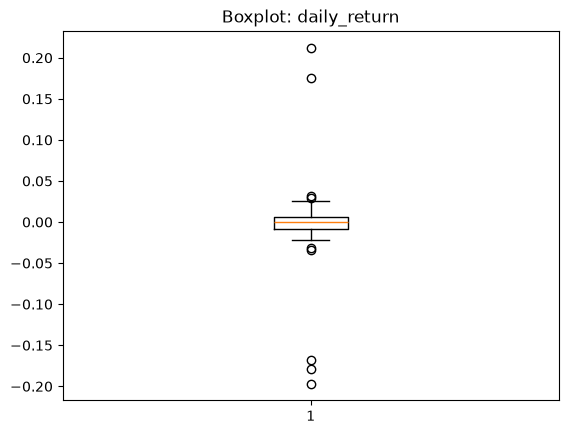

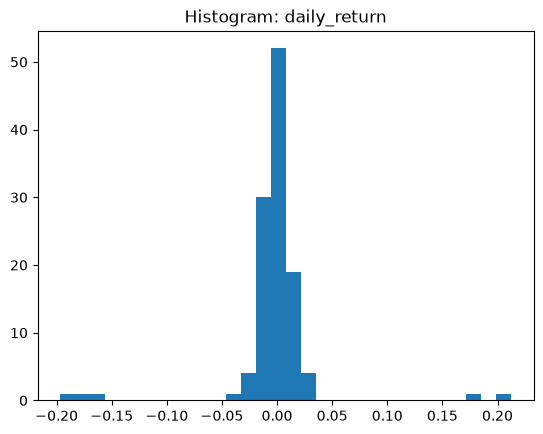

In [55]:
plt.figure()
plt.boxplot(df[target_col])
plt.title(f'Boxplot: {target_col}')
plt.show()

plt.figure()
plt.hist(df[target_col], bins=30)
plt.title(f'Histogram: {target_col}')
plt.show()

## Sensitivity Analysis
Pick one: summary stats or simple linear regression comparing **all vs. filtered** (and optional winsorized).

In [56]:
# Option A: Summary stats
summ_all = df[target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_filtered = df.loc[~df['outlier_iqr'], target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_w = None
if 'winsorize_series' in globals():
    w = winsorize_series(df[target_col])
    summ_w = w.describe()[['mean', '50%', 'std']].rename({'50%': 'median'})

comp = pd.concat(
    {
        'all': summ_all,
        'filtered_iqr': summ_filtered,
        **({'winsorized': summ_w} if summ_w is not None else {})
    }, axis=1
)
comp

,all,filtered_iqr,winsorized
mean,-0.001434,-0.000039,-0.000251
median,-0.000187,-0.000100,-0.000187
std,0.040579,0.009443,0.010623


In [57]:
# Option B: Simple regression - did removing the outliers give us a BETTER model?
# The dataset has two correlated numeric columns, so regress one on the other.
resp_col = [c for c in df.columns
            if c != target_col and c != 'date' and not str(c).startswith('outlier_')][0]
print('regressing %s on %s' % (resp_col, target_col))

keep = ~df['outlier_iqr']            # the IQR flag from the cell above
X_all = df[[target_col]].to_numpy(); y_all = df[resp_col].to_numpy()
X_filtered = df.loc[keep, [target_col]].to_numpy(); y_filtered = df.loc[keep, resp_col].to_numpy()

model_all = LinearRegression().fit(X_all, y_all)
model_flt = LinearRegression().fit(X_filtered, y_filtered)

mae_all = mean_absolute_error(y_all, model_all.predict(X_all))
mae_flt = mean_absolute_error(y_filtered, model_flt.predict(X_filtered))

results = pd.DataFrame({
    'slope': [model_all.coef_[0], model_flt.coef_[0]],
    'intercept': [model_all.intercept_, model_flt.intercept_],
    'r2': [model_all.score(X_all, y_all), model_flt.score(X_filtered, y_filtered)],
    'mae': [mae_all, mae_flt]
}, index=['all', 'filtered_iqr'])

# Read the r2 column before you conclude that removing outliers helped.
results

regressing daily_return_2 on daily_return


,slope,intercept,r2,mae
all,0.605869,0.000201,0.961859,0.003951
filtered_iqr,0.589679,-0.000049,0.573566,0.003851


### Reflection (≤ 1 page)
- Methods and thresholds used (and why)
- Assumptions behind choices
- Observed impact on results
- Risks if assumptions are wrong (e.g., discarding true events)

*I used both the IQR method and the Z-score method to identify outliers in `daily_return`. 

For the IQR method, I used the standard 1.5IQR rule because it does not require the data to be normally distributed. For the Z-score method, I used a threshold of 3.0, which marks observations that are far from the mean. The IQR method identified about 7.83% of the observations as outliers, while the Z-score method identified about 4.35%. This difference shows that the choice of method and threshold can affect which observations are considered unusual.

The main assumption behind the IQR method is that the quartiles provide a reasonable description of the typical range of the data. The Z-score method relies more heavily on the mean and sd and works better when the distribution is approximately normal. The histogram and boxplot show that most daily returns are concentrated near zero, but there are several very large positive and negative returns, so the distribution has extreme tails.

Removing the IQR outliers had a significant effect on the results. The sd decreased from about 0.0406 for the full dataset to 0.0094 after filtering. Winsorizing produced a sd of about 0.0106. The mean also moved much closer to zero after filtering. This shows that a small number of extreme observations can have a large impact on summary statistics.

However, removing outliers also creates risk. In financial return data, an extreme observation may represent a real market event rather than an error. If the assumptions behind the detection method are wrong, removing these observations could hide important information and underestimate risk. Therefore, outlier handling should depend on the purpose of the analysis rather than automatically deleting every flagged observation.*